# Bernoulli Matrix Factorization

Implementamos un modelo de **Bernoulli Matrix Factorization** para recomendación implícita. A diferencia de los modelos que predicen directamente una valoración numérica, este enfoque transforma el problema en una tarea binaria: predecir si a un usuario le gustará o no una receta.

Para ello, se utiliza la variable `liked`, donde una interacción se considera positiva cuando el usuario ha mostrado una preferencia favorable por la receta. El modelo aprende representaciones latentes de usuarios y recetas mediante embeddings y estima la probabilidad de interacción positiva usando una función sigmoide.

Este enfoque resulta adecuado cuando se quiere trabajar con señales implícitas o binarias, como me gusta/no me gusta, interacción/no interacción o relevante/no relevante.

**Autores:** Gallo Álvaro, García Álvaro, Recover Diego, Rízquez Tello

> Nota: Para obtener más información sobre el proyecto puedes consultar el repositorio original en [GitHub](https://github.com/DiegoRecover8/Food.com-Recommender-Systems).

## Importaciones

Se importan las librerías necesarias para cargar los datos, construir el modelo, entrenarlo con PyTorch y evaluar sus resultados mediante métricas de clasificación y ranking.

In [21]:
# Librerías básicas
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss
)

# Utilidades
from tqdm import tqdm

## Configuración inicial

Fijamos una semilla para hacer el entrenamiento más reproducible y seleccionamos el dispositivo de cálculo. Si hay GPU disponible, se utilizará `cuda`; en caso contrario, se usará CPU.

In [22]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo utilizado:", device)

Dispositivo utilizado: cpu


## Carga de datos

Cargamos el conjunto de entrenamiento implícito, que contiene la columna binaria `liked`. Para validación y test se utilizan los conjuntos limpios con ratings explícitos, transformando después la valoración en una etiqueta binaria.

Se considera que una receta es positiva o relevante si su `rating` es mayor o igual que 4.

In [23]:
train = pd.read_csv("../data/processed/interactions_train_implicit.csv")
validation = pd.read_csv("../data/processed/interactions_validation_clean.csv")
test = pd.read_csv("../data/processed/interactions_test_clean.csv")

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (698901, 6)
Validation: (7023, 6)
Test: (12455, 6)


## Preparación de la variable binaria

El entrenamiento ya contiene la columna `liked`. Para validación y test, generamos la misma variable a partir de `rating`. Usamos el umbral 4 porque normalmente los ratings 4 y 5 representan valoraciones positivas.

In [24]:
THETA = 4

validation = validation.copy()
test = test.copy()

validation["liked"] = (validation["rating"] >= THETA).astype(int)
test["liked"] = (test["rating"] >= THETA).astype(int)

print("Distribución de liked en train:")
print(train["liked"].value_counts(normalize=True).rename("proporción"))

print("Distribución de liked en validation:")
print(validation["liked"].value_counts(normalize=True).rename("proporción"))

print("Distribución de liked en test:")
print(test["liked"].value_counts(normalize=True).rename("proporción"))

Distribución de liked en train:
liked
1    0.924265
0    0.075735
Name: proporción, dtype: float64
Distribución de liked en validation:
liked
1    0.840097
0    0.159903
Name: proporción, dtype: float64
Distribución de liked en test:
liked
1    0.834444
0    0.165556
Name: proporción, dtype: float64


## Número de usuarios y recetas

Las capas de embeddings necesitan saber cuántos usuarios y cuántas recetas distintas existen. Se calcula el máximo identificador codificado en las columnas `u` e `i`, sumando 1 porque los índices empiezan en 0.

In [25]:
num_users = int(max(train["u"].max(), validation["u"].max(), test["u"].max())) + 1
num_items = int(max(train["i"].max(), validation["i"].max(), test["i"].max())) + 1

print("Número de usuarios:", num_users)
print("Número de recetas:", num_items)

Número de usuarios: 25076
Número de recetas: 178265


## Dataset y DataLoader

Creamos una clase `Dataset` de PyTorch que devuelve para cada interacción el usuario, la receta y la etiqueta binaria `liked`. Después se crean los `DataLoader`, que permiten entrenar por lotes.

In [26]:
class ImplicitDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df["u"].values, dtype=torch.long)
        self.items = torch.tensor(df["i"].values, dtype=torch.long)
        self.labels = torch.tensor(df["liked"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.labels[idx]

In [27]:
train_dataset = ImplicitDataset(train)
validation_dataset = ImplicitDataset(validation)
test_dataset = ImplicitDataset(test)

batch_size = 4096

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

users_batch, items_batch, labels_batch = next(iter(train_loader))

print("Batch usuarios:", users_batch.shape)
print("Batch recetas:", items_batch.shape)
print("Batch etiquetas:", labels_batch.shape)
print("Ejemplo etiquetas:", labels_batch[:10])

Batch usuarios: torch.Size([4096])
Batch recetas: torch.Size([4096])
Batch etiquetas: torch.Size([4096])
Ejemplo etiquetas: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])


## Definición del modelo Bernoulli Matrix Factorization

El modelo aprende un embedding para cada usuario y otro para cada receta. La afinidad entre ambos se calcula mediante el producto escalar de sus vectores latentes, añadiendo además sesgos de usuario, receta y un sesgo global.

La salida del modelo es un **logit**, es decir, un valor real que posteriormente se transforma en probabilidad mediante una función sigmoide. Esta formulación encaja con una distribución Bernoulli, donde la probabilidad estimada representa la probabilidad de que `liked = 1`.

In [28]:
class BernoulliMF(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=64):
        super(BernoulliMF, self).__init__()

        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        self.user_bias = nn.Embedding(num_users, 1)
        self.item_bias = nn.Embedding(num_items, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.user_embedding.weight, mean=0.0, std=0.01)
        nn.init.normal_(self.item_embedding.weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def forward(self, users, items):
        user_vec = self.user_embedding(users)
        item_vec = self.item_embedding(items)

        interaction = torch.sum(user_vec * item_vec, dim=1)
        user_b = self.user_bias(users).squeeze()
        item_b = self.item_bias(items).squeeze()

        logits = interaction + user_b + item_b + self.global_bias
        return logits

    def predict_proba(self, users, items):
        logits = self.forward(users, items)
        return torch.sigmoid(logits)

In [29]:
embedding_dim = 64

model = BernoulliMF(
    num_users=num_users,
    num_items=num_items,
    embedding_dim=embedding_dim
).to(device)

print(model)

BernoulliMF(
  (user_embedding): Embedding(25076, 64)
  (item_embedding): Embedding(178265, 64)
  (user_bias): Embedding(25076, 1)
  (item_bias): Embedding(178265, 1)
)


## Funciones de evaluación

Para este modelo se utilizan métricas de clasificación binaria. La pérdida principal es la entropía cruzada binaria, y además se calculan accuracy, precision, recall, F1 y AUC.

La predicción final se obtiene comparando la probabilidad estimada con un umbral de 0.5.

In [30]:
def evaluate_binary_model(model, data_loader, criterion=None, threshold=0.5):
    model.eval()

    all_labels = []
    all_probs = []
    total_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for users, items, labels in data_loader:
            users = users.to(device)
            items = items.to(device)
            labels = labels.to(device)

            logits = model(users, items)
            probs = torch.sigmoid(logits)

            if criterion is not None:
                loss = criterion(logits, labels)
                total_loss += loss.item() * len(labels)
                total_examples += len(labels)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_preds = (all_probs >= threshold).astype(int)

    metrics = {
        "loss": total_loss / total_examples if criterion is not None else np.nan,
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
    }

    if len(np.unique(all_labels)) == 2:
        metrics["auc"] = roc_auc_score(all_labels, all_probs)
    else:
        metrics["auc"] = np.nan

    return metrics

## Entrenamiento del modelo

El modelo se entrena minimizando `BCEWithLogitsLoss`, que combina internamente una función sigmoide con la entropía cruzada binaria. Esta opción es más estable numéricamente que aplicar una sigmoide manualmente antes de la pérdida.

Se guarda automáticamente el mejor modelo según la pérdida de validación.

In [31]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

epochs = 10

os.makedirs("models", exist_ok=True)
best_model_path = os.path.join("models", "bernoulli_mf_best.pth")
best_val_loss = float("inf")

train_losses = []
validation_losses = []
validation_aucs = []
validation_f1s = []

In [32]:
for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for users, items, labels in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}"):
        users = users.to(device)
        items = items.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(users, items)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)

    avg_train_loss = total_loss / len(train_dataset)
    val_metrics = evaluate_binary_model(model, validation_loader, criterion=criterion)

    train_losses.append(avg_train_loss)
    validation_losses.append(val_metrics["loss"])
    validation_aucs.append(val_metrics["auc"])
    validation_f1s.append(val_metrics["f1"])

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "validation_loss": val_metrics["loss"],
            "validation_auc": val_metrics["auc"],
            "validation_f1": val_metrics["f1"],
            "num_users": num_users,
            "num_items": num_items,
            "embedding_dim": embedding_dim,
        }, best_model_path)

        print(f"Nuevo mejor modelo guardado en epoch {epoch + 1}")

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val AUC: {val_metrics['auc']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f}"
    )

Epoch 1/10: 100%|██████████| 171/171 [00:14<00:00, 11.61it/s]


Nuevo mejor modelo guardado en epoch 1
Epoch 1/10 | Train Loss: 0.6310 | Val Loss: 0.6265 | Val AUC: 0.6344 | Val F1: 0.9131


Epoch 2/10: 100%|██████████| 171/171 [00:08<00:00, 19.72it/s]


Nuevo mejor modelo guardado en epoch 2
Epoch 2/10 | Train Loss: 0.4896 | Val Loss: 0.5787 | Val AUC: 0.6387 | Val F1: 0.9131


Epoch 3/10: 100%|██████████| 171/171 [00:08<00:00, 20.58it/s]


...

Nuevo mejor modelo guardado en epoch 8
Epoch 8/10 | Train Loss: 0.2786 | Val Loss: 0.4554 | Val AUC: 0.6554 | Val F1: 0.9131


Epoch 9/10: 100%|██████████| 171/171 [00:14<00:00, 12.07it/s]


Nuevo mejor modelo guardado en epoch 9
Epoch 9/10 | Train Loss: 0.2705 | Val Loss: 0.4465 | Val AUC: 0.6573 | Val F1: 0.9131


Epoch 10/10: 100%|██████████| 171/171 [00:11<00:00, 15.02it/s]


Nuevo mejor modelo guardado en epoch 10
Epoch 10/10 | Train Loss: 0.2636 | Val Loss: 0.4398 | Val AUC: 0.6585 | Val F1: 0.9131


## Evolución del entrenamiento

Representamos la evolución de la pérdida en entrenamiento y validación. Si la pérdida de entrenamiento sigue bajando mientras la de validación empieza a subir, podría existir sobreajuste.

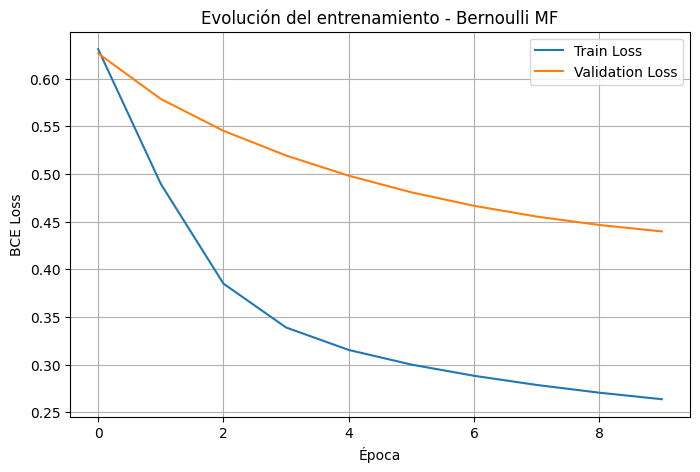

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(validation_losses, label="Validation Loss")

plt.xlabel("Época")
plt.ylabel("BCE Loss")
plt.title("Evolución del entrenamiento - Bernoulli MF")
plt.legend()
plt.grid(True)
plt.show()

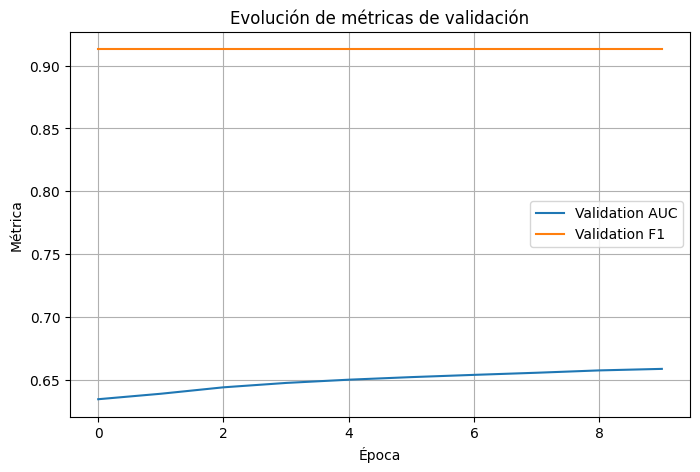

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(validation_aucs, label="Validation AUC")
plt.plot(validation_f1s, label="Validation F1")

plt.xlabel("Época")
plt.ylabel("Métrica")
plt.title("Evolución de métricas de validación")
plt.legend()
plt.grid(True)
plt.show()

## Carga del mejor modelo

Para la evaluación final en test, se carga el checkpoint con mejor pérdida de validación. Esto evita evaluar necesariamente el modelo de la última época, que podría estar sobreajustado.

In [35]:
checkpoint = torch.load(best_model_path, map_location=device)

best_model = BernoulliMF(
    num_users=checkpoint["num_users"],
    num_items=checkpoint["num_items"],
    embedding_dim=checkpoint["embedding_dim"]
).to(device)

best_model.load_state_dict(checkpoint["model_state_dict"])

print("Mejor época:", checkpoint["epoch"])
print("Validation Loss:", checkpoint["validation_loss"])
print("Validation AUC:", checkpoint["validation_auc"])
print("Validation F1:", checkpoint["validation_f1"])

Mejor época: 10
Validation Loss: 0.43975401180991924
Validation AUC: 0.6585316268469746
Validation F1: 0.9131006732182929


## Evaluación en test

Se evalúa el mejor modelo sobre el conjunto de test mediante métricas de clasificación binaria. Estas métricas indican si el modelo distingue correctamente entre recetas relevantes y no relevantes.

In [36]:
test_metrics = evaluate_binary_model(best_model, test_loader, criterion=criterion)

print("Resultados en test - Bernoulli Matrix Factorization")
print(f"Loss: {test_metrics['loss']:.4f}")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall: {test_metrics['recall']:.4f}")
print(f"F1: {test_metrics['f1']:.4f}")
print(f"AUC: {test_metrics['auc']:.4f}")

Resultados en test - Bernoulli Matrix Factorization
Loss: 0.4527
Accuracy: 0.8344
Precision: 0.8344
Recall: 1.0000
F1: 0.9098
AUC: 0.6318


## Predicciones para métricas de ranking

Además de las métricas de clasificación, se calculan métricas de ranking. Para ello, se generan las probabilidades predichas por el modelo y se almacenan en un diccionario con claves `(usuario, receta)`.

In [37]:
def get_probability_dict(model, data_loader):
    model.eval()
    probability_dict = {}

    with torch.no_grad():
        for users, items, labels in data_loader:
            users_device = users.to(device)
            items_device = items.to(device)

            probs = model.predict_proba(users_device, items_device).cpu().numpy()
            users_np = users.cpu().numpy()
            items_np = items.cpu().numpy()

            for u, i, prob in zip(users_np, items_np, probs):
                probability_dict[(int(u), int(i))] = float(prob)

    return probability_dict


bernoulli_predictions = get_probability_dict(best_model, test_loader)

print("Número de predicciones:", len(bernoulli_predictions))
print("Número de filas en test:", len(test))

Número de predicciones: 12455
Número de filas en test: 12455


## Métricas de ranking

Para calcular Precision@N, Recall@N, F1@N y NDCG@N se ordenan las recetas de cada usuario según la probabilidad predicha por el modelo. Después se comprueba si las recetas recomendadas son realmente relevantes.

Como el conjunto de test puede contener pocas interacciones por usuario, estas métricas deben interpretarse con cautela.

In [38]:
test_ratings = {
    (int(row["u"]), int(row["i"])): float(row["liked"])
    for _, row in test.iterrows()
}

test_users = test["u"].unique()

N = 10

def get_user_predictions(predictions, user):
    return {
        item: pred
        for (u, item), pred in predictions.items()
        if u == user
    }


def get_user_ratings(ratings, user):
    return {
        item: rating
        for (u, item), rating in ratings.items()
        if u == user
    }


def precision_at_n(predictions, ratings, users, N=10):
    precisions = []

    for user in users:
        user_preds = get_user_predictions(predictions, user)
        user_true = get_user_ratings(ratings, user)

        if len(user_preds) == 0:
            continue

        top_n_items = sorted(user_preds, key=user_preds.get, reverse=True)[:N]

        relevant_recommended = [
            item for item in top_n_items
            if item in user_true and user_true[item] == 1
        ]

        precisions.append(len(relevant_recommended) / N)

    return np.mean(precisions)


def recall_at_n(predictions, ratings, users, N=10):
    recalls = []

    for user in users:
        user_preds = get_user_predictions(predictions, user)
        user_true = get_user_ratings(ratings, user)

        relevant_items = [
            item for item, rating in user_true.items()
            if rating == 1
        ]

        if len(relevant_items) == 0:
            continue

        top_n_items = sorted(user_preds, key=user_preds.get, reverse=True)[:N]

        relevant_recommended = [
            item for item in top_n_items
            if item in relevant_items
        ]

        recalls.append(len(relevant_recommended) / len(relevant_items))

    return np.mean(recalls)


def f1_at_n(precision, recall):
    if precision + recall == 0:
        return 0
    return 2 * precision * recall / (precision + recall)


def ndcg_at_n(predictions, ratings, users, N=10):
    ndcgs = []

    for user in users:
        user_preds = get_user_predictions(predictions, user)
        user_true = get_user_ratings(ratings, user)

        if len(user_preds) == 0:
            continue

        top_n_items = sorted(user_preds, key=user_preds.get, reverse=True)[:N]

        dcg = 0.0
        for rank, item in enumerate(top_n_items):
            relevance = 1 if item in user_true and user_true[item] == 1 else 0
            dcg += relevance / np.log2(rank + 2)

        ideal_relevances = sorted(
            [1 if rating == 1 else 0 for rating in user_true.values()],
            reverse=True
        )[:N]

        idcg = 0.0
        for rank, relevance in enumerate(ideal_relevances):
            idcg += relevance / np.log2(rank + 2)

        if idcg > 0:
            ndcgs.append(dcg / idcg)

    return np.mean(ndcgs)

In [39]:
precision_bernoulli = precision_at_n(
    bernoulli_predictions,
    test_ratings,
    test_users,
    N=N
)

recall_bernoulli = recall_at_n(
    bernoulli_predictions,
    test_ratings,
    test_users,
    N=N
)

f1_bernoulli = f1_at_n(precision_bernoulli, recall_bernoulli)

ndcg_bernoulli = ndcg_at_n(
    bernoulli_predictions,
    test_ratings,
    test_users,
    N=N
)

print(f"Precision@{N}: {precision_bernoulli:.4f}")
print(f"Recall@{N}: {recall_bernoulli:.4f}")
print(f"F1@{N}: {f1_bernoulli:.4f}")
print(f"NDCG@{N}: {ndcg_bernoulli:.4f}")

Precision@10: 0.0834
Recall@10: 1.0000
F1@10: 0.1540
NDCG@10: 1.0000


## Resumen de resultados

Se resumen las métricas principales del modelo Bernoulli Matrix Factorization.

In [40]:
# Creamos el modelo de baseline


item_pop = train.groupby("i")["liked"].mean().to_dict()
global_like_rate = float(train["liked"].mean())  # fallback si un item no aparece en train

# Predicciones baseline para EXACTAMENTE los pares del test
baseline_predictions = {
    (int(row["u"]), int(row["i"])): float(item_pop.get(int(row["i"]), global_like_rate))
    for _, row in test.iterrows()
}

# Métricas ranking baseline reutilizando las funciones
precision_base = precision_at_n(baseline_predictions, test_ratings, test_users, N=N)
recall_base = recall_at_n(baseline_predictions, test_ratings, test_users, N=N)
f1_base_rank = f1_at_n(precision_base, recall_base)
ndcg_base = ndcg_at_n(baseline_predictions, test_ratings, test_users, N=N)

# Métricas clasificación baseline  
y_true = np.array([test_ratings[k] for k in test_ratings.keys()], dtype=int)
y_score = np.array([baseline_predictions[k] for k in test_ratings.keys()], dtype=float)
y_pred = (y_score >= 0.5).astype(int)

baseline_loss = log_loss(y_true, y_score, labels=[0, 1])
baseline_acc = accuracy_score(y_true, y_pred)
baseline_prec = precision_score(y_true, y_pred, zero_division=0)
baseline_rec = recall_score(y_true, y_pred, zero_division=0)
baseline_f1 = f1_score(y_true, y_pred, zero_division=0)
baseline_auc = roc_auc_score(y_true, y_score) if len(np.unique(y_true)) > 1 else np.nan

results_compare = pd.DataFrame([
    {
        "Modelo": "Baseline (media global)",
        "Loss": baseline_loss,
        "Accuracy": baseline_acc,
        "Precision": baseline_prec,
        "Recall": baseline_rec,
        "F1": baseline_f1,
        "AUC": baseline_auc,
        f"Precision@{N}": precision_base,
        f"Recall@{N}": recall_base,
        f"F1@{N}": f1_base_rank,
        f"NDCG@{N}": ndcg_base,
    },
    {
        "Modelo": "Bernoulli Matrix Factorization",
        "Loss": test_metrics["loss"],
        "Accuracy": test_metrics["accuracy"],
        "Precision": test_metrics["precision"],
        "Recall": test_metrics["recall"],
        "F1": test_metrics["f1"],
        "AUC": test_metrics["auc"],
        f"Precision@{N}": precision_bernoulli,
        f"Recall@{N}": recall_bernoulli,
        f"F1@{N}": f1_bernoulli,
        f"NDCG@{N}": ndcg_bernoulli,
    }
])

results_compare

,Modelo,Loss,Accuracy,Precision,Recall,F1,AUC,Precision@10,Recall@10,F1@10,NDCG@10
0,Baseline (media global),0.492938,0.834444,0.834444,1.0,0.909751,0.500000,0.083444,1.0,0.154035,1.0
1,Bernoulli Matrix Factorization,0.452670,0.834444,0.834444,1.0,0.909751,0.631809,0.083444,1.0,0.154035,1.0


## Conclusiones

A diferencia de la factorización matricial orientada a ratings, este enfoque no intenta predecir directamente una puntuación entre 0 y 5, sino una probabilidad binaria de preferencia positiva. Por ello, resulta especialmente útil cuando se trabaja con interacciones implícitas o con datos transformados a formato positivo/negativo.

El entrenamiento se realiza minimizando la entropía cruzada binaria, y el modelo se evalúa mediante métricas de clasificación como accuracy, precision, recall, F1 y AUC. Además, se calculan métricas de ranking para analizar si las recetas relevantes aparecen entre las primeras recomendaciones.

Los resultados muestran que **Bernoulli Matrix Factorization mejora al baseline en métricas de ajuste global**, ya que obtiene **menor loss** (0.4527 vs 0.4929) y un **AUC claramente superior** (0.6318 vs 0.5000). Esto sugiere que el modelo discrimina mejor entre interacciones positivas y negativas que el baseline de popularidad.

Sin embargo, en términos de **clasificación y recomendación top-10**, ambos modelos se comportan prácticamente igual: **accuracy, precision, recall, F1, Precision@10, Recall@10, F1@10 y NDCG@10** son idénticos. En la práctica, esto indica que **la mejora del modelo factorial no se está trasladando al ranking final de recomendaciones**, al menos con esta configuración o con este conjunto de evaluación.
